In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time

# 1. Detect available devices
device_gpu = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device_cpu = torch.device("cpu")
print(f"GPU device: {device_gpu}")
print(f"CPU device: {device_cpu}")

# 2. Load and split the data
data = fetch_california_housing()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42
)

# 3. Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# 4. Create PyTorch datasets & loaders
train_ds = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
)
test_ds = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)
)
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=128)

# 5. Define a simple MLP
class MiniMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

# 6. Function to train and evaluate model on a specific device
def train_and_evaluate(device_name, device):
    print(f"\n--- Running on {device_name} ---")
    
    # Initialize model on the device
    model = MiniMLP(input_dim=X_train.shape[1]).to(device)
    
    # Set up training
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    num_epochs = 5
    
    # Training loop
    train_start_time = time.time()
    for epoch in range(num_epochs):
        model.train()
        epoch_start_time = time.time()
        total_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
        avg_loss = total_loss / len(train_loader.dataset)
        epoch_time = time.time() - epoch_start_time
        print(f"Epoch {epoch+1}/{num_epochs} — Train MSE: {avg_loss:.4f} — Time: {epoch_time:.2f}s")
    
    train_time = time.time() - train_start_time
    print(f"Total training time: {train_time:.2f}s")
    
    # Evaluation
    eval_start_time = time.time()
    model.eval()
    with torch.no_grad():
        total_loss = 0.0
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            total_loss += criterion(preds, yb).item() * xb.size(0)
        test_mse = total_loss / len(test_loader.dataset)
    eval_time = time.time() - eval_start_time
    print(f"Test MSE: {test_mse:.4f} — Evaluation time: {eval_time:.2f}s")
    
    return train_time, eval_time, test_mse

# 7. Run on GPU (if available)
if torch.cuda.is_available():
    gpu_train_time, gpu_eval_time, gpu_mse = train_and_evaluate("GPU", device_gpu)

# 8. Run on CPU
cpu_train_time, cpu_eval_time, cpu_mse = train_and_evaluate("CPU", device_cpu)

# 9. Compare results
if torch.cuda.is_available():
    print("\n--- Performance Comparison ---")
    print(f"GPU Training Time: {gpu_train_time:.2f}s | CPU Training Time: {cpu_train_time:.2f}s | Speedup: {cpu_train_time/gpu_train_time:.2f}x")
    print(f"GPU Evaluation Time: {gpu_eval_time:.2f}s | CPU Evaluation Time: {cpu_eval_time:.2f}s | Speedup: {cpu_eval_time/gpu_eval_time:.2f}x")
    print(f"GPU Test MSE: {gpu_mse:.4f} | CPU Test MSE: {cpu_mse:.4f}")


In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import optuna
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import fetch_california_housing           # ← changed
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm
import time
import numpy as np

seeds = [1,2,3]
iter = 1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1) Search space (updated)
param_grid = {
    "n_layers":      [1, 2, 3],
    "n_units_l0":    [32, 96, 160, 224],
    "n_units_l1":    [32, 96, 160, 224],
    "n_units_l2":    [32, 96, 160, 224],
    "activation":    ["relu", "tanh"],                           # ← added
    "optimizer":     ["adam", "sgd"],                            # ← added
    "learning_rate": [0.0001, 0.001, 0.01],                      # ← reduced values for grid search
    "batch_size":    [32, 96, 160, 224],
    "dropout_rate":  [0.0, 0.2, 0.4],                            # ← reduced values for grid search
    "weight_decay":  [1e-6, 1e-4, 1e-2],                         # ← reduced values for grid search
}

# 2) Data prep (regression)
X, y = fetch_california_housing(return_X_y=True, as_frame=False)  # ← changed
X = StandardScaler().fit_transform(X.astype('float32'))
y = y.astype('float32').reshape(-1,1)
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=iter
)
train_ds = TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr))
test_ds  = TensorDataset(torch.from_numpy(X_te), torch.from_numpy(y_te))

# 3) Model (with dropout & activation selection)
class OptunaRegNet(nn.Module):
    def __init__(self, trial):
        super().__init__()
        # suggest depth & widths
        n_layers      = trial.suggest_categorical("n_layers", param_grid["n_layers"])
        hidden_sizes  = []
        if n_layers >= 1:
            hidden_sizes.append(trial.suggest_categorical("n_units_l0", param_grid["n_units_l0"]))
        if n_layers >= 2:
            hidden_sizes.append(trial.suggest_categorical("n_units_l1", param_grid["n_units_l1"]))
        if n_layers >= 3:
            hidden_sizes.append(trial.suggest_categorical("n_units_l2", param_grid["n_units_l2"]))

        self.activation   = nn.ReLU() if trial.suggest_categorical("activation", param_grid["activation"])=="relu" else nn.Tanh()  # ← added
        self.dropout_rate = trial.suggest_categorical("dropout_rate", param_grid["dropout_rate"])                                                    # ← added

        layers = []
        in_dim = X.shape[1]
        for h in hidden_sizes:
            layers.append(nn.Linear(in_dim, h))
            layers.append(self.activation)
            layers.append(nn.Dropout(self.dropout_rate))
            in_dim = h
        self.net    = nn.Sequential(*layers)
        self.output = nn.Linear(in_dim, 1)

    def forward(self, x):
        x = self.net(x)
        return self.output(x)

# 4) Objective (with float/log LR, optimizer choice & weight_decay)
def objective(trial):
    model = OptunaRegNet(trial).to(device)

    lr  = trial.suggest_categorical("learning_rate", param_grid["learning_rate"])                                               # ← changed
    wd  = trial.suggest_categorical("weight_decay", param_grid["weight_decay"])                                               # ← added
    bs  = trial.suggest_categorical("batch_size", param_grid["batch_size"])

    # choose optimizer
    opt_name = trial.suggest_categorical("optimizer", param_grid["optimizer"])
    optimizer = (torch.optim.Adam if opt_name=="adam" else torch.optim.SGD)(
        model.parameters(), lr=lr, weight_decay=wd                                                        # ← added wd
    )

    train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True)
    test_loader  = DataLoader(test_ds,  batch_size=bs, shuffle=False)
    loss_fn      = nn.MSELoss(reduction='sum')                                                              # ← changed to regression

    # training
    try:
        for _ in range(30):
            model.train()
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                outputs = model(xb)
                loss = loss_fn(outputs, yb)
                
                # Check for NaN loss
                if torch.isnan(loss).any():
                    print(f"NaN loss detected during training with params: {trial.params}")
                    raise optuna.exceptions.TrialPruned("NaN loss encountered")
                
                loss.backward()
                
                # Gradient clipping to prevent exploding gradients
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                
                optimizer.step()
                
                # Check for NaN weights after update
                for param in model.parameters():
                    if torch.isnan(param).any():
                        print(f"NaN weights detected after update with params: {trial.params}")
                        raise optuna.exceptions.TrialPruned("NaN weights encountered")

        # evaluation
        model.eval()
        total_loss = 0.0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                
                # Check for NaN outputs
                if torch.isnan(outputs).any():
                    print(f"NaN outputs detected during evaluation with params: {trial.params}")
                    raise optuna.exceptions.TrialPruned("NaN outputs encountered")
                
                batch_loss = loss_fn(outputs, yb).item()
                
                # Check for NaN loss
                if np.isnan(batch_loss):
                    print(f"NaN loss detected during evaluation with params: {trial.params}")
                    raise optuna.exceptions.TrialPruned("NaN evaluation loss encountered")
                
                total_loss += batch_loss

        avg_mse = total_loss / len(test_ds)
        
        # Final check for NaN result
        if np.isnan(avg_mse):
            print(f"NaN final MSE with params: {trial.params}")
            raise optuna.exceptions.TrialPruned("NaN final MSE encountered")
            
        trial.set_user_attr("mse", avg_mse)
        return -avg_mse  # maximize negative MSE
    
    except Exception as e:
        print(f"Error in trial with params {trial.params}: {str(e)}")
        raise optuna.exceptions.TrialPruned(f"Trial failed with error: {str(e)}")

# 5) Logging callback remains the same, but record "mse"
results = []
def logging_callback(study, trial):
    entry = trial.params.copy()
    entry["neg_mse"]      = trial.value
    entry["trial_number"] = trial.number
    entry["trial_end"]    = time.time()
    entry["mse"]          = trial.user_attrs["mse"]
    results.append(entry)
    pbar.update(1)


In [ ]:
import time
import json
from tqdm.auto import tqdm
from optuna.samplers import GridSampler
from sklearn.model_selection import ParameterGrid
import numpy as np

# Maximum runtime per grid search (1.75 hours in seconds)
MAX_RUNTIME = 1.75 * 60 * 60

# Seeds for reproducibility
grid_seeds = [0, 1, 2]



# Function to run a single grid search with time limit
def run_grid_search(seed_idx):
    global results
    
    # Set seed for reproducibility
    np.random.seed(grid_seeds[seed_idx])
    torch.manual_seed(grid_seeds[seed_idx])
    
    # Reset results for this run
    results = []
    start_time = time.time()
    results.append({"start_time": start_time})
    
    # Create grid sampler
    sampler = GridSampler(param_grid)
    study = optuna.create_study(direction="maximize", sampler=sampler)
    
    # Calculate number of trials in the grid
    n_trials = len(list(ParameterGrid(param_grid)))
    print(f"Running grid search {seed_idx+1}/3 with seed {grid_seeds[seed_idx]}")
    print(f"Grid contains {n_trials} configurations")
    
    # Setup progress bar based on time rather than iterations
    global pbar
    start_time = time.time()
    results.append({"start_time": start_time})
    pbar = tqdm(total=MAX_RUNTIME, desc=f"Grid Search (seed={grid_seeds[seed_idx]})")
    
    # Time-based progress bar update function
    def time_based_callback(study, trial):
        # Update the regular logging
        entry = trial.params.copy()
        entry["neg_mse"] = trial.value
        entry["trial_number"] = trial.number
        entry["trial_end"] = time.time()
        entry["mse"] = trial.user_attrs["mse"]
        results.append(entry)
        
        # Update progress bar based on elapsed time
        elapsed = time.time() - start_time
        pbar.n = min(elapsed, MAX_RUNTIME)
        pbar.refresh()
    
    # Run optimization with time limit
    study.optimize(
        objective,
        n_trials=n_trials,
        n_jobs=5,
        callbacks=[time_based_callback],
        timeout=MAX_RUNTIME
    )
    
    # Ensure progress bar is complete
    pbar.n = MAX_RUNTIME
    pbar.refresh()
    pbar.close()
    
    # Save results
    with open(f"results/GRID/results_{seed_idx+1}.json", "w") as f:
        json.dump(results, f, indent=2)
    
    # Print best result
    print(f"Grid search {seed_idx+1} completed")
    print(f"Best negative MSE: {study.best_value}")
    print(f"Best hyperparameters: {study.best_trial.params}")
    print(f"Runtime: {(time.time() - start_time) / 60:.2f} minutes")
    print("-" * 50)
    
    return study.best_value, study.best_trial.params

# Create directory if it doesn't exist
import os
os.makedirs("results/GRID", exist_ok=True)

# Run all three grid searches sequentially
best_configs = []
for i in [0, 1, 2]:
    best_value, best_params = run_grid_search(i)
    best_configs.append((best_value, best_params))


In [2]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import optuna
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm
import json
import time
import numpy as np

seeds = [1, 2, 3]
iter = 1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
start_time = time.time()

# 1) Search space with continuous parameters|
param_grid = {
    "n_layers":      [1, 2, 3],
    "n_units_l0":    [32, 256],  # min and max bounds
    "n_units_l1":    [32, 256],  # min and max bounds
    "n_units_l2":    [32, 256],  # min and max bounds
    "activation":    ["relu", "tanh"],
    "optimizer":     ["adam", "sgd"],
    "learning_rate": [0.0001, 0.001, 0.01],
    "batch_size":    [32, 256],  # min and max bounds
    "dropout_rate":  [0.0, 0.2, 0.4],
    "weight_decay":  [1e-6, 1e-4, 1e-2],
}

# 2) Data prep (regression)
X, y = fetch_california_housing(return_X_y=True, as_frame=False)
X = StandardScaler().fit_transform(X.astype('float32'))
y = y.astype('float32').reshape(-1,1)
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=iter
)
train_ds = TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr))
test_ds  = TensorDataset(torch.from_numpy(X_te), torch.from_numpy(y_te))

# 3) Model (with dropout & activation selection)
class OptunaRegNet(nn.Module):
    def __init__(self, trial):
        super().__init__()
        # suggest depth & widths
        n_layers      = trial.suggest_categorical("n_layers", param_grid["n_layers"])
        hidden_sizes  = []
        if n_layers >= 1:
            hidden_sizes.append(trial.suggest_int("n_units_l0", param_grid["n_units_l0"][0], param_grid["n_units_l0"][1]))
        if n_layers >= 2:
            hidden_sizes.append(trial.suggest_int("n_units_l1", param_grid["n_units_l1"][0], param_grid["n_units_l1"][1]))
        if n_layers >= 3:
            hidden_sizes.append(trial.suggest_int("n_units_l2", param_grid["n_units_l2"][0], param_grid["n_units_l2"][1]))

        self.activation   = nn.ReLU() if trial.suggest_categorical("activation", param_grid["activation"])=="relu" else nn.Tanh()
        self.dropout_rate = trial.suggest_categorical("dropout_rate", param_grid["dropout_rate"])

        layers = []
        in_dim = X.shape[1]
        for h in hidden_sizes:
            layers.append(nn.Linear(in_dim, h))
            layers.append(self.activation)
            layers.append(nn.Dropout(self.dropout_rate))
            in_dim = h
        self.net    = nn.Sequential(*layers)
        self.output = nn.Linear(in_dim, 1)

    def forward(self, x):
        x = self.net(x)
        return self.output(x)

# 4) Objective (with float/log LR, optimizer choice & weight_decay)
def objective(trial):
    model = OptunaRegNet(trial).to(device)

    lr  = trial.suggest_categorical("learning_rate", param_grid["learning_rate"])
    wd  = trial.suggest_categorical("weight_decay", param_grid["weight_decay"])
    bs  = trial.suggest_int("batch_size", param_grid["batch_size"][0], param_grid["batch_size"][1])

    # choose optimizer
    opt_name = trial.suggest_categorical("optimizer", param_grid["optimizer"])
    optimizer = (torch.optim.Adam if opt_name=="adam" else torch.optim.SGD)(
        model.parameters(), lr=lr, weight_decay=wd
    )

    train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True)
    test_loader  = DataLoader(test_ds,  batch_size=bs, shuffle=False)
    loss_fn      = nn.MSELoss(reduction='sum')

    # training
    try:
        for _ in range(30):
            model.train()
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                outputs = model(xb)
                loss = loss_fn(outputs, yb)
                
                # Check for NaN loss
                if torch.isnan(loss).any():
                    print(f"NaN loss detected during training with params: {trial.params}")
                    raise optuna.exceptions.TrialPruned("NaN loss encountered")
                
                loss.backward()
                
                # Gradient clipping to prevent exploding gradients
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                
                optimizer.step()
                
                # Check for NaN weights after update
                for param in model.parameters():
                    if torch.isnan(param).any():
                        print(f"NaN weights detected after update with params: {trial.params}")
                        raise optuna.exceptions.TrialPruned("NaN weights encountered")

        # evaluation
        model.eval()
        total_loss = 0.0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                
                # Check for NaN outputs
                if torch.isnan(outputs).any():
                    print(f"NaN outputs detected during evaluation with params: {trial.params}")
                    raise optuna.exceptions.TrialPruned("NaN outputs encountered")
                
                batch_loss = loss_fn(outputs, yb).item()
                
                # Check for NaN loss
                if np.isnan(batch_loss):
                    print(f"NaN loss detected during evaluation with params: {trial.params}")
                    raise optuna.exceptions.TrialPruned("NaN evaluation loss encountered")
                
                total_loss += batch_loss

        avg_mse = total_loss / len(test_ds)
        
        # Final check for NaN result
        if np.isnan(avg_mse):
            print(f"NaN final MSE with params: {trial.params}")
            raise optuna.exceptions.TrialPruned("NaN final MSE encountered")
            
        trial.set_user_attr("mse", avg_mse)
        return -avg_mse  # maximize negative MSE
    
    except Exception as e:
        print(f"Error in trial with params {trial.params}: {str(e)}")
        raise optuna.exceptions.TrialPruned(f"Trial failed with error: {str(e)}")

# 5) Logging callback
results = []
def logging_callback(study, trial):
    entry = trial.params.copy()
    entry["neg_mse"]      = trial.value
    entry["trial_number"] = trial.number
    entry["trial_end"]    = time.time()
    entry["mse"]          = trial.user_attrs["mse"]
    results.append(entry)
    
    # Update progress bar based on elapsed time
    elapsed = time.time() - start_time
    pbar.n = min(elapsed, MAX_RUNTIME)
    pbar.refresh()


In [ ]:
import optuna
from optuna.samplers import RandomSampler

# Maximum runtime per random search (1.75 hours in seconds)
MAX_RUNTIME = 1.75 * 60 * 60

# Seeds for reproducibility
random_seeds = [0, 0, 4]

start_time = time.time()
# Function to run a single random search with time limit
def run_random_search(seed_idx):
    global results
    
    # Set seed for reproducibility
    np.random.seed(random_seeds[seed_idx])
    torch.manual_seed(random_seeds[seed_idx])
    
    # Reset results for this run
    results = []
    start_time = time.time()
    results.append({"start_time": start_time})
    
    # Create random sampler
    sampler = RandomSampler(seed=random_seeds[seed_idx])
    study = optuna.create_study(direction="maximize", sampler=sampler)
    
    # Number of trials for random search
    n_trials = 450
    
    print(f"Running random search {seed_idx+1}/3 with seed {random_seeds[seed_idx]}")
    print(f"Will run up to {n_trials} configurations")
    
    # Setup progress bar
    global pbar
    pbar = tqdm(total=MAX_RUNTIME, desc=f"Random Search (seed={random_seeds[seed_idx]})")
    
    # Record start time
    start_time = time.time()
    results.append({"start_time": start_time})
    
    # Run optimization with time limit
    study.optimize(
        objective,
        n_trials=n_trials,
        n_jobs=5,
        callbacks=[logging_callback],
        timeout=MAX_RUNTIME
    )
    
    # Close progress bar
    pbar.close()
    
    # Save results
    with open(f"results/RANDOM/results_{seed_idx+1}.json", "w") as f:
        json.dump(results, f, indent=2)
    
    # Print best result
    print(f"Random search {seed_idx+1} completed")
    print(f"Best negative MSE: {study.best_value}")
    print(f"Best hyperparameters: {study.best_trial.params}")
    print(f"Runtime: {(time.time() - start_time) / 60:.2f} minutes")
    print("-" * 50)
    
    return study.best_value, study.best_trial.params

# Create directory if it doesn't exist
import os
os.makedirs("results/RANDOM", exist_ok=True)

# Run all three random searches sequentially
best_random_configs = []
for i in [0,1,2]:
    best_value, best_params = run_random_search(i)
    best_random_configs.append((best_value, best_params))


In [ ]:
import optuna
from optuna.samplers import TPESampler
import time
import json
import numpy as np
import torch
from tqdm.notebook import tqdm

dir = "results/TPE"

# Maximum runtime per TPE search (1.75 hours in seconds)
MAX_RUNTIME = 1.75 * 60 * 60

# Seeds for reproducibility
tpe_seeds = [7, 8, 9]

# Parameters to test (one factor at a time)
consider_prior_values = [True, False]
consider_magic_clip_values = [True, False]
consider_endpoints_values = [True, False]

# Function to run a single TPE search with time limit
def run_tpe_search(seed_idx, param_name, param_value):
    global results
    
    # Set seed for reproducibility
    np.random.seed(tpe_seeds[seed_idx])
    torch.manual_seed(tpe_seeds[seed_idx])
    
    # Reset results for this run
    results = []
    start_time = time.time()
    results.append({"start_time": start_time})
    
    # Create TPE sampler with varying parameters
    if param_name == "consider_prior":
        sampler = TPESampler(seed=tpe_seeds[seed_idx], consider_prior=param_value)
    elif param_name == "consider_magic_clip":
        sampler = TPESampler(seed=tpe_seeds[seed_idx], consider_magic_clip=param_value)
    elif param_name == "consider_endpoints":
        sampler = TPESampler(seed=tpe_seeds[seed_idx], consider_endpoints=param_value)
    
    study = optuna.create_study(direction="maximize", sampler=sampler)
    
    # Number of trials for TPE search
    n_trials = 450
    
    print(f"Running TPE search {seed_idx+1}/3 with seed {tpe_seeds[seed_idx]} ({param_name}={param_value})")
    print(f"Will run up to {n_trials} configurations")
    
    # Setup progress bar
    global pbar
    pbar = tqdm(total=MAX_RUNTIME, desc=f"TPE Search (seed={tpe_seeds[seed_idx]})")
    
    # Run optimization with time limit
    study.optimize(
        objective,
        n_trials=n_trials,
        n_jobs=5,
        callbacks=[logging_callback],
        timeout=MAX_RUNTIME
    )
    
    # Close progress bar
    pbar.close()

    # Save results
    os.makedirs(f"{dir}/{param_name}/{param_name}={param_value}", exist_ok=True)
    with open(f"{dir}/{param_name}/{param_name}={param_value}/results_{seed_idx+1}.json", "w") as f:
        json.dump(results, f, indent=2)
    
    # Print best result
    print(f"TPE search {seed_idx+1} completed")
    print(f"Best negative MSE: {study.best_value}")
    print(f"Best hyperparameters: {study.best_trial.params}")
    print(f"Runtime: {(time.time() - start_time) / 60:.2f} minutes")
    print("-" * 50)
    
    return study.best_value, study.best_trial.params

# Test consider_prior parameter
for consider_prior in consider_prior_values:
    # Create directory if it doesn't exist
    os.makedirs(f"{dir}/consider_prior/consider_prior={consider_prior}", exist_ok=True)

    # Run all three TPE searches sequentially
    best_tpe_configs = []
    for i in range(3):
        best_value, best_params = run_tpe_search(i, "consider_prior", consider_prior)
        best_tpe_configs.append((best_value, best_params))

# Test consider_magic_clip parameter
for consider_magic_clip in consider_magic_clip_values:
    # Create directory if it doesn't exist
    os.makedirs(f"{dir}/consider_magic_clip/consider_magic_clip={consider_magic_clip}", exist_ok=True)

    # Run all three TPE searches sequentially
    best_tpe_configs = []
    for i in range(3):
        best_value, best_params = run_tpe_search(i, "consider_magic_clip", consider_magic_clip)
        best_tpe_configs.append((best_value, best_params))

# Test consider_endpoints parameter
for consider_endpoints in consider_endpoints_values:
    # Create directory if it doesn't exist
    os.makedirs(f"{dir}/consider_endpoints/consider_endpoints={consider_endpoints}", exist_ok=True)

    # Run all three TPE searches sequentially
    best_tpe_configs = []
    for i in range(3):
        best_value, best_params = run_tpe_search(i, "consider_endpoints", consider_endpoints)
        best_tpe_configs.append((best_value, best_params))


In [5]:
# CMA-ES Optimization
from optuna.samplers import CmaEsSampler

# Maximum runtime per CMA-ES search (1.75 hours in seconds)
MAX_RUNTIME = 1.75 * 60 * 60

# Seeds for reproducibility
cmaes_seeds = [10, 11, 12]

# OFAT parameter values to test (only remaining parameters)
lr_adapt_values = [True, False]

# Function to run a single CMA-ES search with time limit
def run_cmaes_search(seed_idx, param_name, param_value):
    global results
    
    # Set seed for reproducibility
    np.random.seed(cmaes_seeds[seed_idx])
    torch.manual_seed(cmaes_seeds[seed_idx])
    
    # Reset results for this run
    results = []
    start_time = time.time()
    results.append({"start_time": start_time})
    
    # Create CMA-ES sampler with varying parameters
    # Note: CMA-ES has issues with mixed parameter types (categorical + continuous)
    # The error occurs because CMA-ES expects all parameters to be continuous
    # but our search space includes categorical parameters
    if param_name == "lr_adapt":
        sampler = CmaEsSampler(
            seed=cmaes_seeds[seed_idx], 
            lr_adapt=param_value,
            warn_independent_sampling=True  # Suppress warnings about mixed types
        )
    
    study = optuna.create_study(direction="maximize", sampler=sampler)
    
    # Number of trials for CMA-ES search
    n_trials = 425
    
    print(f"Running CMA-ES search {seed_idx+1}/3 with seed {cmaes_seeds[seed_idx]}")
    print(f"Testing {param_name}={param_value}")
    print(f"Will run up to {n_trials} configurations")
    print("Note: CMA-ES will use independent sampling for categorical parameters")
    
    # Setup progress bar
    global pbar
    pbar = tqdm(total=MAX_RUNTIME, desc=f"CMA-ES Search (seed={cmaes_seeds[seed_idx]})")
    
    # Run optimization with time limit
    study.optimize(
        objective,
        n_trials=n_trials,
        n_jobs=1,  # Keep at 1 to avoid parallelization issues
        callbacks=[logging_callback],
        timeout=MAX_RUNTIME
    )
    
    # Close progress bar
    pbar.close()
    
    # Save results
    os.makedirs(f"results/CMAES/{param_name}/{param_name}={param_value}", exist_ok=True)
    with open(f"results/CMAES/{param_name}/{param_name}={param_value}/results_{seed_idx+1}.json", "w") as f:
        json.dump(results, f, indent=2)
    
    # Print best result
    print(f"CMA-ES search {seed_idx+1} completed")
    print(f"Best negative MSE: {study.best_value}")
    print(f"Best hyperparameters: {study.best_trial.params}")
    print(f"Runtime: {(time.time() - start_time) / 60:.2f} minutes")
    print("-" * 50)
    
    return study.best_value, study.best_trial.params

# Test lr_adapt parameter
for lr_adapt in lr_adapt_values:
    # Create directory if it doesn't exist
    os.makedirs(f"results/CMAES/lr_adapt/lr_adapt={lr_adapt}", exist_ok=True)

    # Run all three CMA-ES searches sequentially
    best_cmaes_configs = []
    for i in range(3):
        best_value, best_params = run_cmaes_search(i, "lr_adapt", lr_adapt)
        best_cmaes_configs.append((best_value, best_params))

c:\Users\16073\HPOptimization\.venv\Lib\site-packages\optuna\_experimental.py:31: ExperimentalWarning: Argument ``lr_adapt`` is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2025-07-06 09:20:31,034] A new study created in memory with name: no-name-a88bbe11-7b41-4013-a618-b5c9ef37156c


Running CMA-ES search 1/3 with seed 10
Testing lr_adapt=True
Will run up to 425 configurations
Note: CMA-ES will use independent sampling for categorical parameters


CMA-ES Search (seed=10):   0%|          | 0/6300.0 [00:00<?, ?it/s]

[I 2025-07-06 09:20:41,954] Trial 0 finished with value: -0.39150546548902526 and parameters: {'n_layers': 1, 'n_units_l0': 200, 'activation': 'relu', 'dropout_rate': 0.2, 'learning_rate': 0.01, 'weight_decay': 0.01, 'batch_size': 169, 'optimizer': 'adam'}. Best is trial 0 with value: -0.39150546548902526.
[W 2025-07-06 09:20:41,956] The parameter 'n_layers' in trial#1 is sampled independently by using `RandomSampler` instead of `CmaEsSampler` (optimization performance may be degraded). `CmaEsSampler` does not support dynamic search space or `CategoricalDistribution`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `CmaEsSampler`, if this independent sampling is intended behavior.
[W 2025-07-06 09:20:41,957] The parameter 'activation' in trial#1 is sampled independently by using `RandomSampler` instead of `CmaEsSampler` (optimization performance may be degraded). `CmaEsSampler` does not support dynamic search space or `CategoricalDi

CMA-ES search 1 completed
Best negative MSE: -0.27361842940828596
Best hyperparameters: {'n_layers': 2, 'n_units_l0': 165, 'n_units_l1': 207, 'activation': 'relu', 'dropout_rate': 0.2, 'learning_rate': 0.001, 'weight_decay': 1e-06, 'batch_size': 71, 'optimizer': 'adam'}
Runtime: 105.07 minutes
--------------------------------------------------
Running CMA-ES search 2/3 with seed 11
Testing lr_adapt=True
Will run up to 425 configurations
Note: CMA-ES will use independent sampling for categorical parameters


...

[I 2025-07-06 15:48:50,703] Trial 0 finished with value: -0.2690159109558246 and parameters: {'n_layers': 3, 'n_units_l0': 195, 'n_units_l1': 126, 'n_units_l2': 141, 'activation': 'tanh', 'dropout_rate': 0.0, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'batch_size': 58, 'optimizer': 'adam'}. Best is trial 0 with value: -0.2690159109558246.
[W 2025-07-06 15:48:50,705] The parameter 'n_layers' in trial#1 is sampled independently by using `RandomSampler` instead of `CmaEsSampler` (optimization performance may be degraded). `CmaEsSampler` does not support dynamic search space or `CategoricalDistribution`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `CmaEsSampler`, if this independent sampling is intended behavior.
[W 2025-07-06 15:48:50,706] The parameter 'activation' in trial#1 is sampled independently by using `RandomSampler` instead of `CmaEsSampler` (optimization performance may be degraded). `CmaEsSampler` does not support 

CMA-ES search 2 completed
Best negative MSE: -0.2690159109558246
Best hyperparameters: {'n_layers': 3, 'n_units_l0': 195, 'n_units_l1': 126, 'n_units_l2': 141, 'activation': 'tanh', 'dropout_rate': 0.0, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'batch_size': 58, 'optimizer': 'adam'}
Runtime: 94.51 minutes
--------------------------------------------------
Running CMA-ES search 3/3 with seed 12
Testing lr_adapt=False
Will run up to 425 configurations
Note: CMA-ES will use independent sampling for categorical parameters


CMA-ES Search (seed=12):   0%|          | 0/6300.0 [00:00<?, ?it/s]

[I 2025-07-06 17:23:03,373] Trial 0 finished with value: -0.398790250452914 and parameters: {'n_layers': 2, 'n_units_l0': 152, 'n_units_l1': 35, 'activation': 'relu', 'dropout_rate': 0.2, 'learning_rate': 0.01, 'weight_decay': 1e-06, 'batch_size': 156, 'optimizer': 'sgd'}. Best is trial 0 with value: -0.398790250452914.
[W 2025-07-06 17:23:03,376] The parameter 'n_layers' in trial#1 is sampled independently by using `RandomSampler` instead of `CmaEsSampler` (optimization performance may be degraded). `CmaEsSampler` does not support dynamic search space or `CategoricalDistribution`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `CmaEsSampler`, if this independent sampling is intended behavior.
[W 2025-07-06 17:23:03,377] The parameter 'activation' in trial#1 is sampled independently by using `RandomSampler` instead of `CmaEsSampler` (optimization performance may be degraded). `CmaEsSampler` does not support dynamic search space or 

CMA-ES search 3 completed
Best negative MSE: -0.26228067948836686
Best hyperparameters: {'n_layers': 3, 'n_units_l0': 173, 'n_units_l1': 205, 'n_units_l2': 73, 'activation': 'tanh', 'dropout_rate': 0.0, 'learning_rate': 0.001, 'weight_decay': 1e-06, 'batch_size': 100, 'optimizer': 'adam'}
Runtime: 105.07 minutes
--------------------------------------------------


In [ ]:
# GP Optimization
from optuna.samplers import GPSampler

# Maximum runtime per GP search (1.75 hours in seconds)
MAX_RUNTIME = 1.75 * 60 * 60

# Seeds for reproducibility
gp_seeds = [13, 14, 15]

# Different n_startup_trials values to test
n_startup_trials = [0, 5, 15, 20, 25]

# Function to run a single GP search with time limit
def run_gp_search(seed_idx, n_startup_trial):
    global results
    
    # Set seed for reproducibility
    np.random.seed(gp_seeds[seed_idx])
    torch.manual_seed(gp_seeds[seed_idx])
    
    # Reset results for this run
    results = []
    start_time = time.time()
    results.append({"start_time": start_time})
    
    # Create GP sampler
    sampler = GPSampler(
        seed=gp_seeds[seed_idx],
        deterministic_objective=False,
        n_startup_trials=n_startup_trial
    )
    study = optuna.create_study(direction="maximize", sampler=sampler)
    
    # Number of trials for GP search
    n_trials = 425
    
    print(f"Running GP search {seed_idx+1}/3 with seed {gp_seeds[seed_idx]}")
    print(f"Will run up to {n_trials} configurations")
    
    # Setup progress bar
    global pbar
    pbar = tqdm(total=MAX_RUNTIME, desc=f"GP Search (seed={gp_seeds[seed_idx]})")
    
    # Run optimization with time limit
    study.optimize(
        objective,
        n_trials=n_trials,
        n_jobs=5,
        callbacks=[logging_callback],
        timeout=MAX_RUNTIME
    )
    
    # Close progress bar
    pbar.close()
    
    # Save results
    os.makedirs(f"results/GP/n_startup_trials={n_startup_trial}", exist_ok=True)
    with open(f"results/GP/n_startup_trials={n_startup_trial}/results_{seed_idx+1}.json", "w") as f:
        json.dump(results, f, indent=2)
    
    # Print best result
    print(f"GP search {seed_idx+1} completed")
    print(f"Best negative MSE: {study.best_value}")
    print(f"Best hyperparameters: {study.best_trial.params}")
    print(f"Runtime: {(time.time() - start_time) / 60:.2f} minutes")
    print("-" * 50)
    
    return study.best_value, study.best_trial.params

for n_startup_trial in n_startup_trials:
    # Create directory if it doesn't exist
    os.makedirs(f"results/GP/n_startup_trials={n_startup_trial}", exist_ok=True)

    # Run all three GP searches sequentially
    best_gp_configs = []
    for i in range(3):
        best_value, best_params = run_gp_search(i, n_startup_trial)
        best_gp_configs.append((best_value, best_params))


In [6]:
import sys
import os
import time
import optuna
import json
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

# NEW: Simple import since package is installed in venv
from hyperband_sampler import HyperbandStudy

# Load and prepare data
data = fetch_california_housing()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42
)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X = torch.tensor(X_train, dtype=torch.float32)
y = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Create datasets
train_ds = TensorDataset(X, y)
test_ds = TensorDataset(X_test_tensor, y_test_tensor)

optuna.logging.set_verbosity(optuna.logging.WARNING)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

MAX_RUNTIME = 1.75 * 60 * 60

seeds = [16, 17, 18]

# Create directory if it doesn't exist
os.makedirs("results/HYPERBAND", exist_ok=True)

# Define reduction factors to test
reduction_factors = [2, 3, 4, 5]

# Define min resource
min_resource = 4

# 1) Search space with continuous parameters
param_grid = {
    "n_layers":      [1, 2, 3],
    "n_units_l0":    [32, 256],  # min and max bounds
    "n_units_l1":    [32, 256],  # min and max bounds
    "n_units_l2":    [32, 256],  # min and max bounds
    "activation":    ["relu", "tanh"],
    "optimizer":     ["adam", "sgd"],
    "learning_rate": [0.0001, 0.001, 0.01],
    "batch_size":    [32, 256],  # min and max bounds
    "dropout_rate":  [0.0, 0.2, 0.4],
    "weight_decay":  [1e-6, 1e-4, 1e-2],
}

class OptunaRegNet(nn.Module):
    def __init__(self, trial):
        super().__init__()
        # suggest depth & widths
        n_layers      = trial.suggest_categorical("n_layers", param_grid["n_layers"])
        hidden_sizes  = []
        if n_layers >= 1:
            hidden_sizes.append(trial.suggest_int("n_units_l0", param_grid["n_units_l0"][0], param_grid["n_units_l0"][1]))
        if n_layers >= 2:
            hidden_sizes.append(trial.suggest_int("n_units_l1", param_grid["n_units_l1"][0], param_grid["n_units_l1"][1]))
        if n_layers >= 3:
            hidden_sizes.append(trial.suggest_int("n_units_l2", param_grid["n_units_l2"][0], param_grid["n_units_l2"][1]))

        self.activation   = nn.ReLU() if trial.suggest_categorical("activation", param_grid["activation"])=="relu" else nn.Tanh()
        self.dropout_rate = trial.suggest_categorical("dropout_rate", param_grid["dropout_rate"])

        layers = []
        in_dim = X.shape[1]
        for h in hidden_sizes:
            layers.append(nn.Linear(in_dim, h))
            layers.append(self.activation)
            layers.append(nn.Dropout(self.dropout_rate))
            in_dim = h
        self.net    = nn.Sequential(*layers)
        self.output = nn.Linear(in_dim, 1)

    def forward(self, x):
        x = self.net(x)
        return self.output(x)

# Loop through each reduction factor
os.makedirs("results/HYPERBAND/mr=4", exist_ok=True)
for r in reduction_factors:
    os.makedirs(f"results/HYPERBAND/mr=4/n={r}", exist_ok=True)
    
    for seed_idx, seed in enumerate(seeds):
        # 4) Objective (modified for Hyperband)
        def objective(trial):
            model = OptunaRegNet(trial).to(device)
            lr = trial.suggest_categorical("learning_rate", param_grid["learning_rate"])
            wd = trial.suggest_categorical("weight_decay", param_grid["weight_decay"])
            bs = trial.suggest_int("batch_size", param_grid["batch_size"][0], param_grid["batch_size"][1])
            optimizer_name = trial.suggest_categorical("optimizer", param_grid["optimizer"])
            
            # Resource parameter controlled by Hyperband
            epochs = trial.suggest_int("resource", 1, 100)
            
            train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True)
            test_loader  = DataLoader(test_ds, batch_size=bs, shuffle=False)
            
            # Select optimizer
            if optimizer_name == "adam":
                opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
            else:
                opt = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=wd)
                
            loss_fn = nn.MSELoss(reduction='sum')
            
            # Train for the number of epochs determined by Hyperband
            for _ in range(int(epochs)):
                model.train()
                for xb, yb in train_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    opt.zero_grad()
                    outputs = model(xb)
                    loss = loss_fn(outputs, yb)
                    
                    # Check for NaN loss and skip if found
                    if torch.isnan(loss):
                        print(f"NaN loss detected, skipping batch")
                        continue
                        
                    loss.backward()
                    
                    # Add gradient clipping to prevent exploding gradients
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    
                    opt.step()
            
            # Evaluate
            model.eval()
            total_loss = 0
            total = 0
            with torch.no_grad():
                for xb, yb in test_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    outputs = model(xb)
                    loss = loss_fn(outputs, yb).item()
                    total_loss += loss
                    total += yb.size(0)
            mse = total_loss / total
            trial.set_user_attr('mse', mse)
            return -mse  # We want to maximize negative MSE (minimize MSE)

        ## 5) Logging callback
        results = []
        def logging_callback(study, trial):
            entry = trial.params.copy()
            entry["neg_mse"]      = trial.value
            entry["trial_number"] = trial.number
            entry["trial_end"]    = time.time()
            entry["mse"]          = trial.user_attrs["mse"]
            results.append(entry)
        
        # 6) Create Hyperband study
        hyperband_study = HyperbandStudy(
            directions="maximize",
            min_resource=min_resource, 
            max_resource=30, 
            reduction_factor=r,
            hyperband_iterations=200,
            sampler_seed=seed
        )

        # Show bracket structure
        print(f"Running Hyperband search with reduction factor r={r}, {seed_idx+1}/3 with seed {seed}")
        print("Hyperband bracket structure:")
        print(f"Total trials needed: {hyperband_study.n_trials}")
        for j, bracket in enumerate(hyperband_study.sampler._brackets):
            print(f"Bracket {j}: {len(bracket['rungs'])} rungs")
            for k, rung in enumerate(bracket['rungs']):
                print(f"  Rung {k}: {rung['n_configs']} trials × {rung['resource']} epochs")

        # 7) Prepare logging and run optimization
        pbar = tqdm(total=hyperband_study.n_trials, desc=f"Hyperband Search (seed={seed})")
        
        # Record start time
        start_time = time.time()
        results.append({"start_time": start_time})

        # Add callback and run
        try:
            study = hyperband_study.optimize(
                objective=objective, 
                callbacks=[logging_callback], 
                n_jobs=5,
                timeout=MAX_RUNTIME
            )
            
            # Print best result
            print(f"Hyperband search r={r}, {seed_idx+1} completed")
            print(f"Best negative MSE: {study.best_value}")
            print(f"Best hyperparameters: {study.best_trial.params}")
            print(f"Runtime: {(time.time() - start_time) / 60:.2f} minutes")
        except Exception as e:
            print(f"Hyperband search failed with error: {str(e)}")
            results.append({"error": str(e)})
        finally:
            pbar.close()
            # 8) Save results to JSON
            with open(f"results/HYPERBAND/mr=4/n={r}/results_{seed_idx+1}.json", "w") as f:
                json.dump(results, f, indent=2)
            print("-" * 50)

Using device: cuda
Running Hyperband search with reduction factor r=2, 1/3 with seed 16
Hyperband bracket structure:
Total trials needed: 3400
Bracket 0: 4 rungs
  Rung 0: 4 trials × 4 epochs
  Rung 1: 2 trials × 8 epochs
  Rung 2: 1 trials × 16 epochs
  Rung 3: 1 trials × 30 epochs
Bracket 1: 3 rungs
  Rung 0: 3 trials × 8 epochs
  Rung 1: 1 trials × 16 epochs
  Rung 2: 1 trials × 30 epochs
Bracket 2: 2 rungs
  Rung 0: 3 trials × 16 epochs
  Rung 1: 1 trials × 30 epochs


Hyperband Search (seed=16):   0%|          | 0/3400 [00:00<?, ?it/s]

Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all br

Hyperband Search (seed=16):   0%|          | 0/3400 [1:47:38<?, ?it/s]


Hyperband search failed with error: cannot unpack non-iterable NoneType object
--------------------------------------------------
Running Hyperband search with reduction factor r=2, 2/3 with seed 17
Hyperband bracket structure:
Total trials needed: 3400
Bracket 0: 4 rungs
  Rung 0: 4 trials × 4 epochs
  Rung 1: 2 trials × 8 epochs
  Rung 2: 1 trials × 16 epochs
  Rung 3: 1 trials × 30 epochs
Bracket 1: 3 rungs
  Rung 0: 3 trials × 8 epochs
  Rung 1: 1 trials × 16 epochs
  Rung 2: 1 trials × 30 epochs
Bracket 2: 2 rungs
  Rung 0: 3 trials × 16 epochs
  Rung 1: 1 trials × 30 epochs


...

--------------------------------------------------
Running Hyperband search with reduction factor r=5, 3/3 with seed 18
Hyperband bracket structure:
Total trials needed: 2000
Bracket 0: 3 rungs
  Rung 0: 5 trials × 4 epochs
  Rung 1: 1 trials × 20 epochs
  Rung 2: 1 trials × 30 epochs
Bracket 1: 2 rungs
  Rung 0: 2 trials × 20 epochs
  Rung 1: 1 trials × 30 epochs


Hyperband Search (seed=18):   0%|          | 0/2000 [00:00<?, ?it/s]

Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all br

Hyperband Search (seed=18):   0%|          | 0/2000 [1:46:11<?, ?it/s]

Hyperband algorithm has completed all brackets.
Hyperband search failed with error: cannot unpack non-iterable NoneType object
--------------------------------------------------


In [7]:
import sys
import os
import time
import optuna
import json
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

# NEW: Simple import since package is installed in venv
from hyperband_sampler import HyperbandStudy

# Load and prepare data
data = fetch_california_housing()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42
)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X = torch.tensor(X_train, dtype=torch.float32)
y = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Create datasets
train_ds = TensorDataset(X, y)
test_ds = TensorDataset(X_test_tensor, y_test_tensor)

optuna.logging.set_verbosity(optuna.logging.WARNING)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

MAX_RUNTIME = 1.75 * 60 * 60

seeds = [16, 17, 18]

# Create directory if it doesn't exist
os.makedirs("results/HYPERBAND", exist_ok=True)

# Define reduction factors to test
reduction_factors = [2, 3, 4, 5]

# Define min resource
min_resource = 5

# 1) Search space with continuous parameters
param_grid = {
    "n_layers":      [1, 2, 3],
    "n_units_l0":    [32, 256],  # min and max bounds
    "n_units_l1":    [32, 256],  # min and max bounds
    "n_units_l2":    [32, 256],  # min and max bounds
    "activation":    ["relu", "tanh"],
    "optimizer":     ["adam", "sgd"],
    "learning_rate": [0.0001, 0.001, 0.01],
    "batch_size":    [32, 256],  # min and max bounds
    "dropout_rate":  [0.0, 0.2, 0.4],
    "weight_decay":  [1e-6, 1e-4, 1e-2],
}

class OptunaRegNet(nn.Module):
    def __init__(self, trial):
        super().__init__()
        # suggest depth & widths
        n_layers      = trial.suggest_categorical("n_layers", param_grid["n_layers"])
        hidden_sizes  = []
        if n_layers >= 1:
            hidden_sizes.append(trial.suggest_int("n_units_l0", param_grid["n_units_l0"][0], param_grid["n_units_l0"][1]))
        if n_layers >= 2:
            hidden_sizes.append(trial.suggest_int("n_units_l1", param_grid["n_units_l1"][0], param_grid["n_units_l1"][1]))
        if n_layers >= 3:
            hidden_sizes.append(trial.suggest_int("n_units_l2", param_grid["n_units_l2"][0], param_grid["n_units_l2"][1]))

        self.activation   = nn.ReLU() if trial.suggest_categorical("activation", param_grid["activation"])=="relu" else nn.Tanh()
        self.dropout_rate = trial.suggest_categorical("dropout_rate", param_grid["dropout_rate"])

        layers = []
        in_dim = X.shape[1]
        for h in hidden_sizes:
            layers.append(nn.Linear(in_dim, h))
            layers.append(self.activation)
            layers.append(nn.Dropout(self.dropout_rate))
            in_dim = h
        self.net    = nn.Sequential(*layers)
        self.output = nn.Linear(in_dim, 1)

    def forward(self, x):
        x = self.net(x)
        return self.output(x)

os.makedirs("results/HYPERBAND/mr=5", exist_ok=True)
# Loop through each reduction factor
for r in reduction_factors:
    os.makedirs(f"results/HYPERBAND/mr=5/n={r}", exist_ok=True)
    
    for seed_idx, seed in enumerate(seeds):
        # 4) Objective (modified for Hyperband)
        def objective(trial):
            model = OptunaRegNet(trial).to(device)
            lr = trial.suggest_categorical("learning_rate", param_grid["learning_rate"])
            wd = trial.suggest_categorical("weight_decay", param_grid["weight_decay"])
            bs = trial.suggest_int("batch_size", param_grid["batch_size"][0], param_grid["batch_size"][1])
            optimizer_name = trial.suggest_categorical("optimizer", param_grid["optimizer"])
            
            # Resource parameter controlled by Hyperband
            epochs = trial.suggest_int("resource", 1, 100)
            
            train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True)
            test_loader  = DataLoader(test_ds, batch_size=bs, shuffle=False)
            
            # Select optimizer
            if optimizer_name == "adam":
                opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
            else:
                opt = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=wd)
                
            loss_fn = nn.MSELoss(reduction='sum')
            
            # Train for the number of epochs determined by Hyperband
            for _ in range(int(epochs)):
                model.train()
                for xb, yb in train_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    opt.zero_grad()
                    outputs = model(xb)
                    loss = loss_fn(outputs, yb)
                    
                    # Check for NaN loss and skip if found
                    if torch.isnan(loss):
                        print(f"NaN loss detected, skipping batch")
                        continue
                        
                    loss.backward()
                    
                    # Add gradient clipping to prevent exploding gradients
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    
                    opt.step()
            
            # Evaluate
            model.eval()
            total_loss = 0
            total = 0
            with torch.no_grad():
                for xb, yb in test_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    outputs = model(xb)
                    loss = loss_fn(outputs, yb).item()
                    total_loss += loss
                    total += yb.size(0)
            mse = total_loss / total
            trial.set_user_attr('mse', mse)
            return -mse  # We want to maximize negative MSE (minimize MSE)

        ## 5) Logging callback
        results = []
        def logging_callback(study, trial):
            entry = trial.params.copy()
            entry["neg_mse"]      = trial.value
            entry["trial_number"] = trial.number
            entry["trial_end"]    = time.time()
            entry["mse"]          = trial.user_attrs["mse"]
            results.append(entry)
        
        # 6) Create Hyperband study
        hyperband_study = HyperbandStudy(
            directions="maximize",
            min_resource=min_resource, 
            max_resource=30, 
            reduction_factor=r,
            hyperband_iterations=200,
            sampler_seed=seed
        )

        # Show bracket structure
        print(f"Running Hyperband search with reduction factor r={r}, {seed_idx+1}/3 with seed {seed}")
        print("Hyperband bracket structure:")
        print(f"Total trials needed: {hyperband_study.n_trials}")
        for j, bracket in enumerate(hyperband_study.sampler._brackets):
            print(f"Bracket {j}: {len(bracket['rungs'])} rungs")
            for k, rung in enumerate(bracket['rungs']):
                print(f"  Rung {k}: {rung['n_configs']} trials × {rung['resource']} epochs")

        # 7) Prepare logging and run optimization
        pbar = tqdm(total=hyperband_study.n_trials, desc=f"Hyperband Search (seed={seed})")
        
        # Record start time
        start_time = time.time()
        results.append({"start_time": start_time})

        # Add callback and run
        try:
            study = hyperband_study.optimize(
                objective=objective, 
                callbacks=[logging_callback], 
                n_jobs=5,
                timeout=MAX_RUNTIME
            )
            
            # Print best result
            print(f"Hyperband search r={r}, {seed_idx+1} completed")
            print(f"Best negative MSE: {study.best_value}")
            print(f"Best hyperparameters: {study.best_trial.params}")
            print(f"Runtime: {(time.time() - start_time) / 60:.2f} minutes")
        except Exception as e:
            print(f"Hyperband search failed with error: {str(e)}")
            results.append({"error": str(e)})
        finally:
            pbar.close()
            # 8) Save results to JSON
            with open(f"results/HYPERBAND/mr=5/n={r}/results_{seed_idx+1}.json", "w") as f:
                json.dump(results, f, indent=2)
            print("-" * 50)

Using device: cuda
Running Hyperband search with reduction factor r=2, 1/3 with seed 16
Hyperband bracket structure:
Total trials needed: 3400
Bracket 0: 4 rungs
  Rung 0: 4 trials × 5 epochs
  Rung 1: 2 trials × 10 epochs
  Rung 2: 1 trials × 20 epochs
  Rung 3: 1 trials × 30 epochs
Bracket 1: 3 rungs
  Rung 0: 3 trials × 10 epochs
  Rung 1: 1 trials × 20 epochs
  Rung 2: 1 trials × 30 epochs
Bracket 2: 2 rungs
  Rung 0: 3 trials × 20 epochs
  Rung 1: 1 trials × 30 epochs


Hyperband Search (seed=16):   0%|          | 0/3400 [00:00<?, ?it/s]

Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all br

Hyperband Search (seed=16):   0%|          | 0/3400 [1:50:06<?, ?it/s]


Hyperband algorithm has completed all brackets.
Hyperband search failed with error: cannot unpack non-iterable NoneType object
--------------------------------------------------
Running Hyperband search with reduction factor r=2, 2/3 with seed 17
Hyperband bracket structure:
Total trials needed: 3400
Bracket 0: 4 rungs
  Rung 0: 4 trials × 5 epochs
  Rung 1: 2 trials × 10 epochs
  Rung 2: 1 trials × 20 epochs
  Rung 3: 1 trials × 30 epochs
Bracket 1: 3 rungs
  Rung 0: 3 trials × 10 epochs
  Rung 1: 1 trials × 20 epochs
  Rung 2: 1 trials × 30 epochs
Bracket 2: 2 rungs
  Rung 0: 3 trials × 20 epochs
  Rung 1: 1 trials × 30 epochs


...

Hyperband algorithm has completed all brackets.
Hyperband search failed with error: cannot unpack non-iterable NoneType object
--------------------------------------------------
Running Hyperband search with reduction factor r=5, 3/3 with seed 18
Hyperband bracket structure:
Total trials needed: 2000
Bracket 0: 3 rungs
  Rung 0: 5 trials × 5 epochs
  Rung 1: 1 trials × 25 epochs
  Rung 2: 1 trials × 30 epochs
Bracket 1: 2 rungs
  Rung 0: 2 trials × 25 epochs
  Rung 1: 1 trials × 30 epochs


Hyperband Search (seed=18):   0%|          | 0/2000 [00:00<?, ?it/s]

Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all br

Hyperband Search (seed=18):   0%|          | 0/2000 [1:47:11<?, ?it/s]

Hyperband algorithm has completed all brackets.
Hyperband search failed with error: cannot unpack non-iterable NoneType object
--------------------------------------------------


In [ ]:
# Load and compare results from all optimization methods
import json
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import defaultdict
from scipy.interpolate import interp1d

# Define the methods to compare
methods = ["GP", "TPE", "RANDOM", "HYPERBAND", "CMAES"]
colors = {
    "GP": "blue",
    "TPE": "green",
    "RANDOM": "red",
    "HYPERBAND": "purple",
    "CMAES": "orange"
}

# Function to load and combine results from multiple runs
def load_results(method):
    results_list = []
    
    if method == "HYPERBAND":
        # Load from all HYPERBAND folders
        try:
            for r in [2, 3, 4]:  # Different reduction factor values
                for i in range(1, 4):  # Load results_1.json, results_2.json, results_3.json
                    file_path = f"results/{method}/n={r}/results_{i}.json"
                    if os.path.exists(file_path):
                        with open(file_path, "r") as f:
                            results_list.append(json.load(f))
                    else:
                        print(f"Warning: File not found - {file_path}")
        except Exception as e:
            print(f"Error loading {method} results: {e}")
    else:
        # Other methods are stored in method/default/
        try:
            for i in range(1, 4):  # Load results_1.json, results_2.json, results_3.json
                file_path = f"results/{method}/default/results_{i}.json"
                if os.path.exists(file_path):
                    with open(file_path, "r") as f:
                        results_list.append(json.load(f))
                else:
                    print(f"Warning: File not found - {file_path}")
        except Exception as e:
            print(f"Error loading {method} results: {e}")
    
    return results_list

# Load results for each method
all_results = {}
for method in methods:
    results = load_results(method)
    if results:
        all_results[method] = results

# Function to extract time series data from a single run
def extract_time_series(results):
    if len(results) <= 1:  # Not enough data
        return None, None
    
    # First entry contains start_time
    if isinstance(results[0], dict) and "start_time" in results[0]:
        start_time = results[0]["start_time"]
        result_entries = results[1:]  # Skip the first entry with start_time
    else:
        # If first entry doesn't have start_time, use the first trial_end as reference
        start_time = min([r.get("trial_end", 0) for r in results if "trial_end" in r])
        result_entries = results
    
    times = []
    mses = []
    best_mse_so_far = float('inf')
    
    for entry in result_entries:
        if "mse" in entry and "trial_end" in entry:
            rel_time = entry["trial_end"] - start_time
            mse = entry["mse"]
            best_mse_so_far = min(best_mse_so_far, mse)
            
            times.append(rel_time)
            mses.append(best_mse_so_far)
    
    # Sort by time to ensure proper plotting
    sorted_data = sorted(zip(times, mses))
    if sorted_data:
        times, mses = zip(*sorted_data)
        return times, mses
    
    return None, None

# Process results for each method and average across runs
plot_data = {}
for method, results_list in all_results.items():
    # Find the best MSE across all runs
    best_mses = []
    time_series_data = []
    
    for results in results_list:
        times, mses = extract_time_series(results)
        if times and mses:
            time_series_data.append((times, mses))
            best_mses.append(min(mses))
    
    if time_series_data:
        # Use the first run's time points as reference for interpolation
        ref_times = np.linspace(0, max([max(times) for times, _ in time_series_data]), 100)
        
        # Interpolate each run's data to the reference time points
        interp_mses = []
        
        for times, mses in time_series_data:
            if len(times) > 1:  # Need at least 2 points for interpolation
                mse_interp = interp1d(times, mses, bounds_error=False, fill_value=(mses[0], mses[-1]))
                interp_mses.append(mse_interp(ref_times))
        
        # Average the interpolated curves
        if interp_mses:
            avg_mses = np.mean(interp_mses, axis=0)
            
            plot_data[method] = {
                "times": ref_times,
                "mses": avg_mses,
                "best_mse": np.mean(best_mses)
            }

# Find the best overall MSE across all methods
best_overall_mse = min([data["best_mse"] for data in plot_data.values()])

# Create the MSE plot
plt.figure(figsize=(12, 8))

for method, data in plot_data.items():
    if "times" in data and "mses" in data:
        plt.plot(data["times"], data["mses"], label=f"{method} (Avg: {data['best_mse']:.4f})", 
                 color=colors[method], linewidth=2)

# Add horizontal line for best MSE
plt.axhline(y=best_overall_mse, color='black', linestyle='--', linewidth=2, 
            label=f'Best Overall MSE: {best_overall_mse:.4f}')

plt.xlabel("Time (seconds)", fontsize=14)
plt.ylabel("Best MSE (lowest)", fontsize=14)
plt.title("Optimization Performance: Average MSE vs Time (all runs)", fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Print final best MSEs (averaged across runs)
print("\nFinal Best MSEs (averaged across all runs):")
for method in sorted(plot_data.keys(), key=lambda x: plot_data[x]["best_mse"]):
    print(f"{method}: {plot_data[method]['best_mse']:.4f}")

plt.show()

# Zoomed in MSE plot (focusing on first 1.5 hours)
plt.figure(figsize=(12, 8))
MAX_TIME = 90 * 60  # 90 minutes = 1.5 hours

for method, data in plot_data.items():
    if "times" in data and "mses" in data:
        # Filter for times less than 1.5 hours
        mask = data["times"] <= MAX_TIME
        if any(mask):
            times = data["times"][mask]
            mses = data["mses"][mask]
            plt.plot(times, mses, label=f"{method} (Avg: {data['best_mse']:.4f})", 
                    color=colors[method], linewidth=2)

# Add horizontal line for best MSE
plt.axhline(y=best_overall_mse, color='black', linestyle='--', linewidth=2, 
            label=f'Best Overall MSE: {best_overall_mse:.4f}')

plt.xlabel("Time (seconds)", fontsize=14)
plt.ylabel("Best MSE (lowest)", fontsize=14)
plt.title("Zoomed Performance: Average MSE vs Time (First 1.5 hours)", fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Find the best performer and set y-axis limits to focus on the lowest loss values
best_method = min(plot_data.keys(), key=lambda x: plot_data[x]["best_mse"])
best_method_mse = plot_data[best_method]["best_mse"]



plt.ylim(0.260, 0.40)
plt.tight_layout()
plt.show()


Loaded: C:/Users/16073/HPOptimization/WIP/phase2/CaliforniaHousing/results/TPE/n_startup_trials/n_startup_trials=0\results_1.json
Loaded: C:/Users/16073/HPOptimization/WIP/phase2/CaliforniaHousing/results/TPE/n_startup_trials/n_startup_trials=0\results_2.json
Loaded: C:/Users/16073/HPOptimization/WIP/phase2/CaliforniaHousing/results/TPE/n_startup_trials/n_startup_trials=0\results_3.json
Loaded: C:/Users/16073/HPOptimization/WIP/phase2/CaliforniaHousing/results/TPE/n_startup_trials/n_startup_trials=5\results_1.json
Loaded: C:/Users/16073/HPOptimization/WIP/phase2/CaliforniaHousing/results/TPE/n_startup_trials/n_startup_trials=5\results_2.json
Loaded: C:/Users/16073/HPOptimization/WIP/phase2/CaliforniaHousing/results/TPE/n_startup_trials/n_startup_trials=5\results_3.json
Loaded: C:/Users/16073/HPOptimization/WIP/phase2/CaliforniaHousing/results/TPE/n_startup_trials/n_startup_trials=10\results_1.json
Loaded: C:/Users/16073/HPOptimization/WIP/phase2/CaliforniaHousing/results/TPE/n_startup_

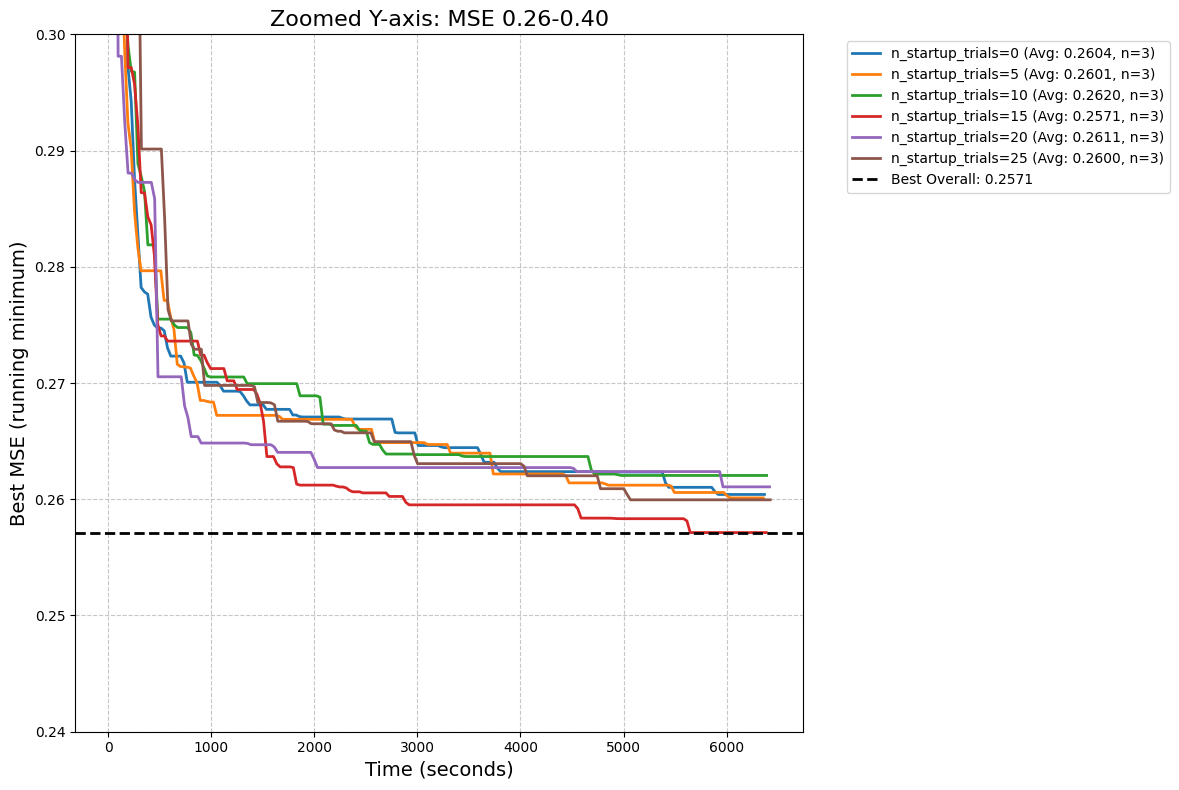

Loaded: C:/Users/16073/HPOptimization/WIP/phase2/CaliforniaHousing/results/TPE/n_startup_trials/n_startup_trials=0\results_1.json
Loaded: C:/Users/16073/HPOptimization/WIP/phase2/CaliforniaHousing/results/TPE/n_startup_trials/n_startup_trials=0\results_2.json
Loaded: C:/Users/16073/HPOptimization/WIP/phase2/CaliforniaHousing/results/TPE/n_startup_trials/n_startup_trials=0\results_3.json
Loaded: C:/Users/16073/HPOptimization/WIP/phase2/CaliforniaHousing/results/TPE/n_startup_trials/n_startup_trials=5\results_1.json
Loaded: C:/Users/16073/HPOptimization/WIP/phase2/CaliforniaHousing/results/TPE/n_startup_trials/n_startup_trials=5\results_2.json
Loaded: C:/Users/16073/HPOptimization/WIP/phase2/CaliforniaHousing/results/TPE/n_startup_trials/n_startup_trials=5\results_3.json
Loaded: C:/Users/16073/HPOptimization/WIP/phase2/CaliforniaHousing/results/TPE/n_startup_trials/n_startup_trials=10\results_1.json
Loaded: C:/Users/16073/HPOptimization/WIP/phase2/CaliforniaHousing/results/TPE/n_startup_

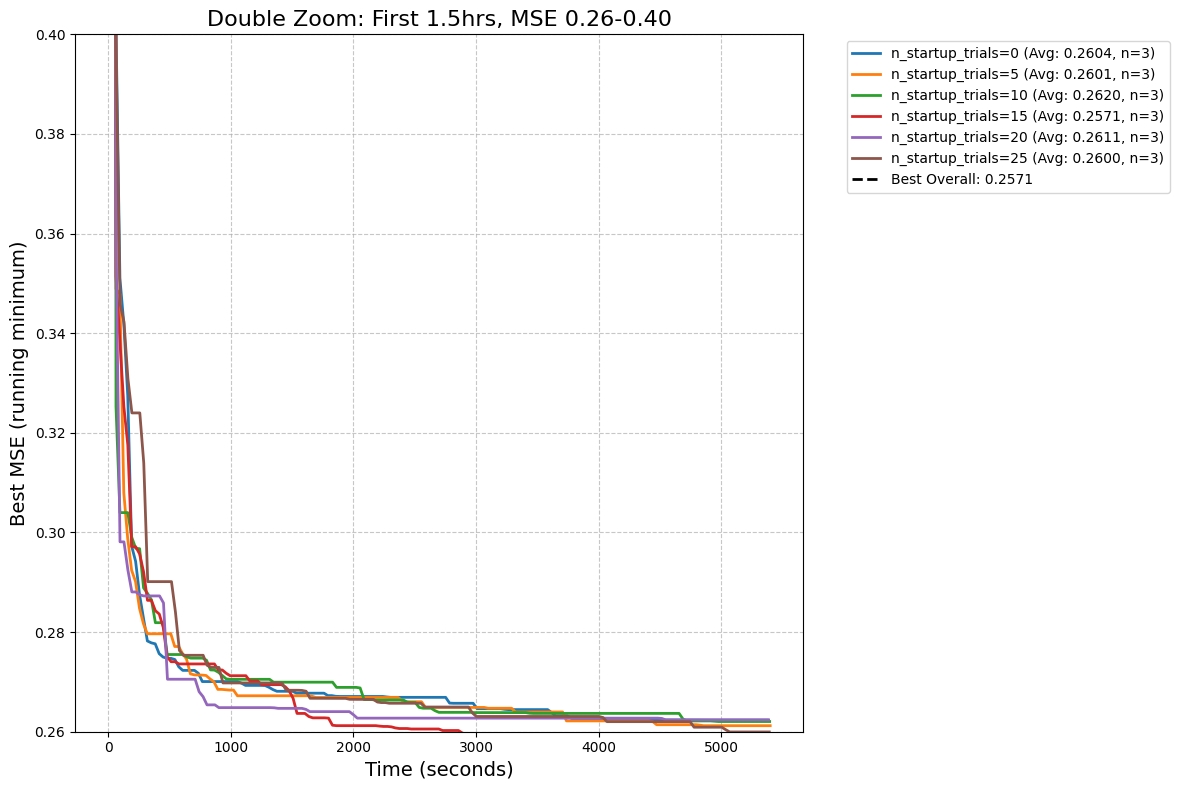

: 

In [ ]:
import json
import os
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d

def plot_optimization_results(directory_paths, title="Optimization Results", max_time=None, y_min=None, y_max=None):
    """
    Plot optimization results from multiple directories.
    
    Args:
        directory_paths: List of directory paths containing results_*.json files
        title: Plot title
        max_time: Maximum time to show (in seconds), None for all data
        y_min: Minimum Y-axis value, None for auto
        y_max: Maximum Y-axis value, None for auto
    """
    
    # Colors for different lines
    colors = [
        "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", 
        "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
        "#aec7e8", "#ffbb78", "#98df8a", "#ff9896", "#c5b0d5",
        "#c49c94", "#f7b6d3", "#c7c7c7", "#dbdb8d", "#9edae5"
    ]
    
    plt.figure(figsize=(12, 8))
    
    all_best_mses = []
    
    for idx, directory in enumerate(directory_paths):
        # Get a short name for the line from the directory path
        line_name = os.path.basename(directory.rstrip('/\\'))
        if not line_name:  # If basename is empty, use parent directory
            line_name = os.path.basename(os.path.dirname(directory))
        
        # Load all results files from this directory
        results_list = []
        for i in range(1, 4):  # Try results_1.json, results_2.json, results_3.json
            file_path = os.path.join(directory, f"results_{i}.json")
            if os.path.exists(file_path):
                try:
                    with open(file_path, "r") as f:
                        results_list.append(json.load(f))
                    print(f"Loaded: {file_path}")
                except Exception as e:
                    print(f"Error loading {file_path}: {e}")
        
        if not results_list:
            print(f"No results found in: {directory}")
            continue
        
        # Process each run and extract time series
        time_series_data = []
        best_mses = []
        
        for results in results_list:
            times, mses = extract_time_series(results)
            if times and mses:
                time_series_data.append((times, mses))
                best_mses.append(min(mses))
        
        if not time_series_data:
            print(f"No valid time series data in: {directory}")
            continue
        
        # Average across runs if multiple runs exist
        if len(time_series_data) > 1:
            # Find common time range
            max_time_data = max([max(times) for times, _ in time_series_data])
            ref_times = np.linspace(0, max_time_data, 200)
            
            # Interpolate each run
            interp_mses = []
            for times, mses in time_series_data:
                if len(times) > 1:
                    mse_interp = interp1d(times, mses, bounds_error=False, 
                                        fill_value=(mses[0], mses[-1]))
                    interp_mses.append(mse_interp(ref_times))
            
            # Average the interpolated curves
            if interp_mses:
                avg_mses = np.mean(interp_mses, axis=0)
                times_to_plot = ref_times
                mses_to_plot = avg_mses
                best_mse = np.mean(best_mses)
                line_label = f"{line_name} (Avg: {best_mse:.4f}, n={len(results_list)})"
        else:
            # Single run
            times_to_plot, mses_to_plot = time_series_data[0]
            best_mse = best_mses[0]
            line_label = f"{line_name} (Best: {best_mse:.4f})"
        
        # Apply time filter if specified
        if max_time is not None:
            mask = np.array(times_to_plot) <= max_time
            times_to_plot = np.array(times_to_plot)[mask]
            mses_to_plot = np.array(mses_to_plot)[mask]
        
        # Plot the line
        color = colors[idx % len(colors)]
        plt.plot(times_to_plot, mses_to_plot, 
                label=line_label, color=color, linewidth=2)
        
        all_best_mses.append(best_mse)
    
    # Add best overall line
    if all_best_mses:
        best_overall = min(all_best_mses)
        plt.axhline(y=best_overall, color='black', linestyle='--', linewidth=2,
                   label=f'Best Overall: {best_overall:.4f}')
    
    plt.xlabel("Time (seconds)", fontsize=14)
    plt.ylabel("Best MSE (running minimum)", fontsize=14)
    plt.title(title, fontsize=16)
    plt.legend(fontsize=10, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Set Y-axis limits if specified
    if y_min is not None or y_max is not None:
        plt.ylim(y_min, y_max)
    
    plt.tight_layout()
    plt.show()

def extract_time_series(results):
    """Extract time series data from a single run"""
    if len(results) <= 1:
        return None, None
    
    # Handle start time
    if isinstance(results[0], dict) and "start_time" in results[0]:
        start_time = results[0]["start_time"]
        result_entries = results[1:]
    else:
        start_time = min([r.get("trial_end", 0) for r in results if "trial_end" in r], default=0)
        result_entries = results
    
    times = []
    mses = []
    best_mse_so_far = float('inf')
    
    for entry in result_entries:
        if "mse" in entry and "trial_end" in entry:
            rel_time = entry["trial_end"] - start_time
            mse = entry["mse"]
            best_mse_so_far = min(best_mse_so_far, mse)
            
            times.append(rel_time)
            mses.append(best_mse_so_far)
    
    if times:
        sorted_data = sorted(zip(times, mses))
        times, mses = zip(*sorted_data)
        return times, mses
    
    return None, None

# Usage: Just copy and paste your directory paths here!
r"""
directories = [
    r"C:\Users\16073\HPOptimization\WIP\phase2\CaliforniaHousing\results\HYPERBAND\mr=5\n=2",
    r"C:\Users\16073\HPOptimization\WIP\phase2\CaliforniaHousing\results\HYPERBAND\mr=5\n=3", 
    r"C:\Users\16073\HPOptimization\WIP\phase2\CaliforniaHousing\results\HYPERBAND\mr=5\n=4",
    r"C:\Users\16073\HPOptimization\WIP\phase2\CaliforniaHousing\results\HYPERBAND\mr=5\n=5"
]
"""

directories = [
    r"C:/Users/16073/HPOptimization/WIP/phase2/CaliforniaHousing/results/TPE/n_startup_trials/n_startup_trials=0",
    r"C:/Users/16073/HPOptimization/WIP/phase2/CaliforniaHousing/results/TPE/n_startup_trials/n_startup_trials=5",
    r"C:/Users/16073/HPOptimization/WIP/phase2/CaliforniaHousing/results/TPE/n_startup_trials/n_startup_trials=10",
    r"C:/Users/16073/HPOptimization/WIP/phase2/CaliforniaHousing/results/TPE/n_startup_trials/n_startup_trials=15",
    r"C:/Users/16073/HPOptimization/WIP/phase2/CaliforniaHousing/results/TPE/n_startup_trials/n_startup_trials=20",
    r"C:/Users/16073/HPOptimization/WIP/phase2/CaliforniaHousing/results/TPE/n_startup_trials/n_startup_trials=25"
]
# Plot all data
#plot_optimization_results(directories, "Optimization Performance: All Time")

# Plot with time zoom (first 1.5 hours)
#plot_optimization_results(directories, "Optimization Performance: First 1.5 Hours", max_time=90*60)

# Plot with Y-axis zoom (focus on lower MSE values)
plot_optimization_results(directories, "Zoomed Y-axis: MSE 0.26-0.40", y_min=0.24, y_max=0.30)

# Plot with both time and Y-axis zoom
plot_optimization_results(directories, "Double Zoom: First 1.5hrs, MSE 0.26-0.40", 
                         max_time=90*60, y_min=0.26, y_max=0.40)